# Exercise 2: Detecting Clique Anomalies in Synthetic Graphs

Generate synthetic graphs with regular structure and cliques, then use the OddBall algorithm to detect clique anomalies.

## Step 1: Import Libraries

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import random
import warnings
warnings.filterwarnings('ignore')

## Step 2: Generate Graphs

In [2]:
# Generate a regular graph with 100 nodes, each with degree 3
G_regular = nx.random_regular_graph(d=3, n=100, seed=42)
print(f"Regular graph: {G_regular.number_of_nodes()} nodes, {G_regular.number_of_edges()} edges")

# Generate a graph with 10 cliques of 20 nodes each
G_cliques = nx.connected_caveman_graph(l=10, k=20)
print(f"Cliques graph: {G_cliques.number_of_nodes()} nodes, {G_cliques.number_of_edges()} edges")

# Merge the two graphs using union
G_merged = nx.union(G_regular, G_cliques, rename=('regular_', 'clique_'))
print(f"Merged graph: {G_merged.number_of_nodes()} nodes, {G_merged.number_of_edges()} edges")

Regular graph: 100 nodes, 150 edges
Cliques graph: 200 nodes, 1900 edges
Merged graph: 300 nodes, 2050 edges


## Step 3: Add Random Edges to Connect the Graph

In [3]:
# Check if graph is connected
print(f"Is connected before adding edges: {nx.is_connected(G_merged)}")

# Add random edges to ensure connectivity
random.seed(42)
nodes_list = list(G_merged.nodes())

# Get nodes from each original graph
regular_nodes = [n for n in nodes_list if n.startswith('regular_')]
clique_nodes = [n for n in nodes_list if n.startswith('clique_')]

# Add random edges between the two subgraphs
num_connecting_edges = 20
for _ in range(num_connecting_edges):
    node1 = random.choice(regular_nodes)
    node2 = random.choice(clique_nodes)
    if not G_merged.has_edge(node1, node2):
        G_merged.add_edge(node1, node2)

print(f"Graph after adding {num_connecting_edges} connecting edges: {G_merged.number_of_nodes()} nodes, {G_merged.number_of_edges()} edges")
print(f"Is connected after adding edges: {nx.is_connected(G_merged)}")

Is connected before adding edges: False
Graph after adding 20 connecting edges: 300 nodes, 2070 edges
Is connected after adding edges: True


## Step 4: Visualize the Merged Graph

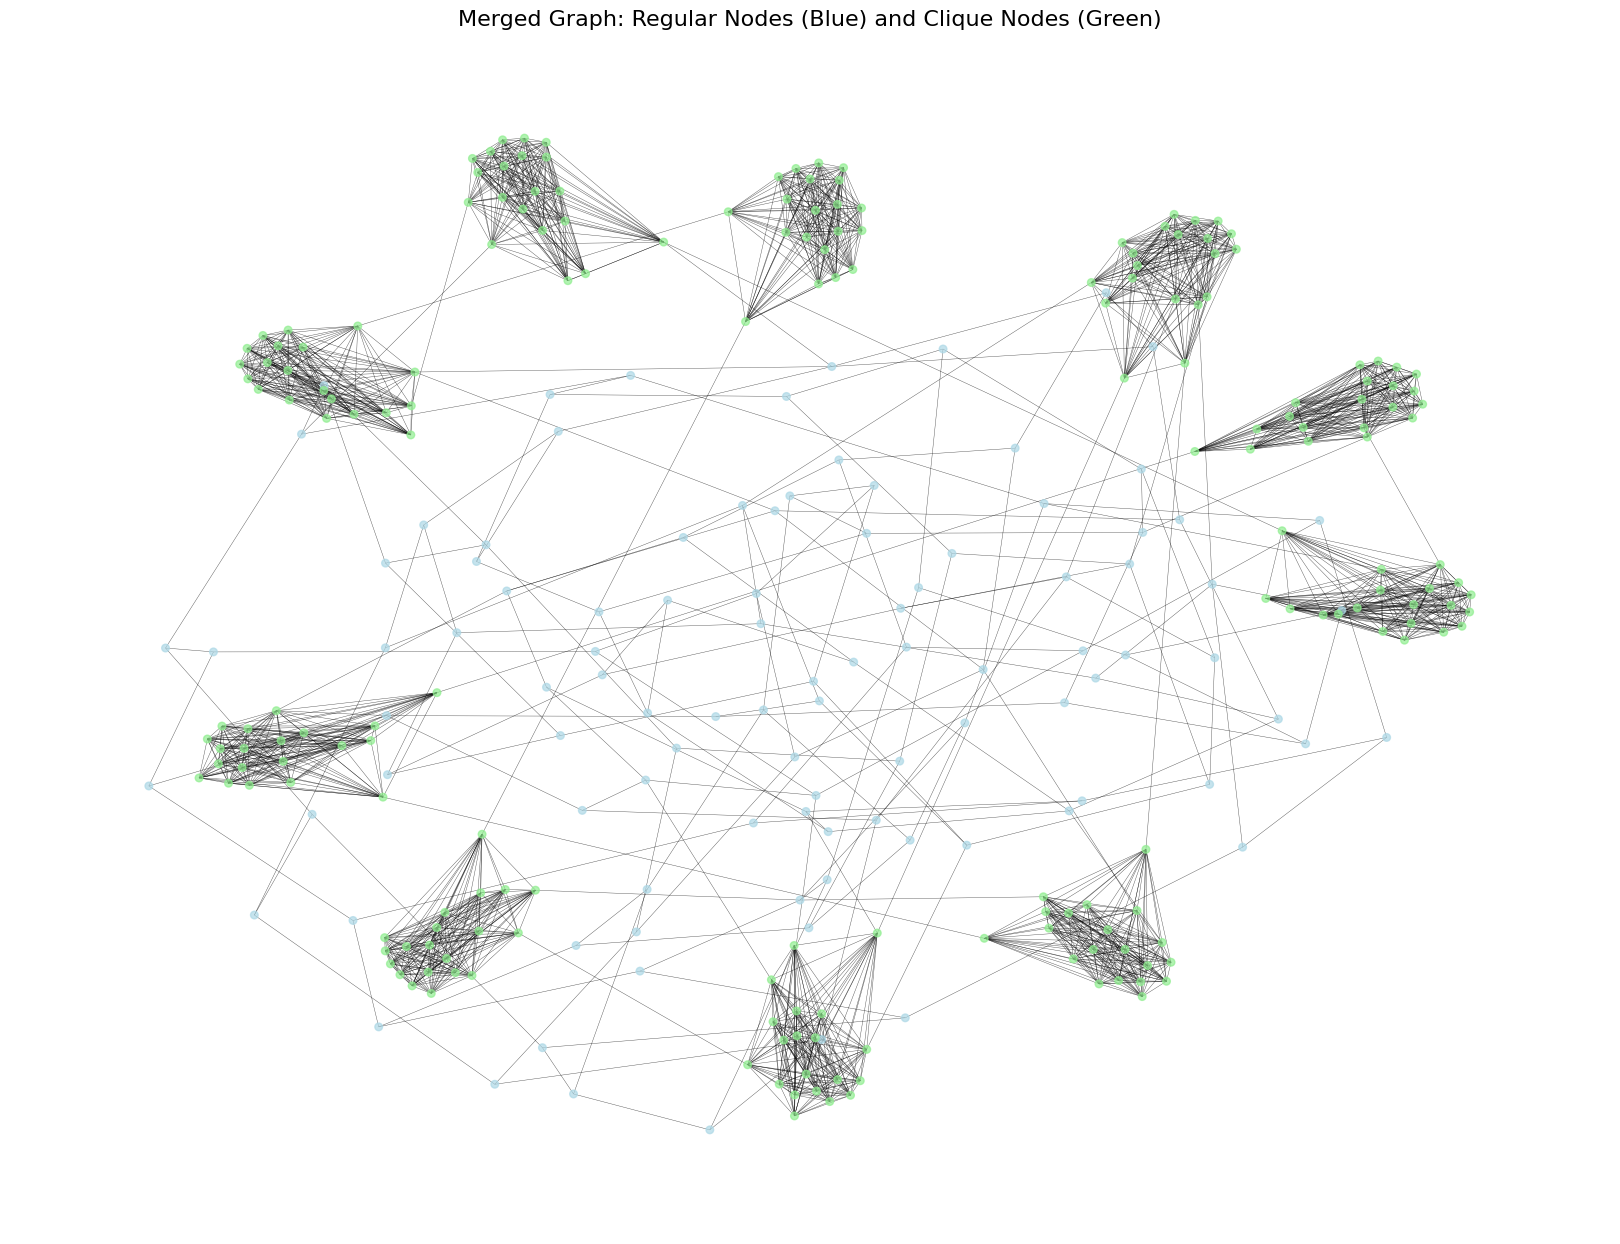

In [4]:
# Draw the merged graph with different colors for regular and clique nodes
node_colors = []
for node in G_merged.nodes():
    if node.startswith('regular_'):
        node_colors.append('lightblue')
    else:
        node_colors.append('lightgreen')

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_merged, k=0.3, iterations=50, seed=42)
nx.draw(G_merged, pos, node_color=node_colors, node_size=30, 
        width=0.3, alpha=0.7, with_labels=False)
plt.title('Merged Graph: Regular Nodes (Blue) and Clique Nodes (Green)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 5: Extract Features (OddBall Algorithm from Exercise 1)

In [5]:
# Extract features for each node
features = {}

for node in G_merged.nodes():
    # Get egonet (subgraph of neighbors)
    egonet = nx.ego_graph(G_merged, node, radius=1)
    
    # Feature 1: Number of neighbors
    num_neighbors = len(list(G_merged.neighbors(node)))
    
    # Feature 2: Number of edges in egonet
    num_edges = egonet.number_of_edges()
    
    # Feature 3: Total weight of egonet
    total_weight = egonet.size(weight='weight')
    
    # Feature 4: Principal eigenvalue of weighted adjacency matrix
    if len(egonet.nodes()) > 1:
        adj_matrix = nx.adjacency_matrix(egonet).todense()
        eigenvalues = np.linalg.eigvalsh(adj_matrix)
        principal_eigenvalue = np.max(eigenvalues)
    else:
        principal_eigenvalue = 0
    
    # Store features
    features[node] = {
        'num_neighbors': num_neighbors,
        'num_edges': num_edges,
        'total_weight': total_weight,
        'principal_eigenvalue': principal_eigenvalue
    }

print(f"Features extracted for {len(features)} nodes")
print(f"Sample features: {list(features.items())[0]}")

Features extracted for 300 nodes
Sample features: ('regular_0', {'num_neighbors': 3, 'num_edges': 3, 'total_weight': 3.0, 'principal_eigenvalue': np.float64(1.7320508075688772)})


## Step 6: Compute Anomaly Scores (Linear Regression on log-scaled features)

In [6]:
# Prepare data for linear regression (num_edges vs num_neighbors in log scale)
nodes_list = list(G_merged.nodes())
X_log = []  # log(num_neighbors)
y_log = []  # log(num_edges)

for node in nodes_list:
    num_neighbors = features[node]['num_neighbors']
    num_edges = features[node]['num_edges']
    
    # Only include nodes with positive values
    if num_neighbors > 0 and num_edges > 0:
        X_log.append(np.log(num_neighbors))
        y_log.append(np.log(num_edges))

X_log = np.array(X_log).reshape(-1, 1)
y_log = np.array(y_log)

# Fit linear regression model: log(y) = log(C) + θ*log(x)
model = LinearRegression()
model.fit(X_log, y_log)

print(f"Linear regression fitted: θ = {model.coef_[0]:.4f}, log(C) = {model.intercept_:.4f}")

# Compute anomaly scores for all nodes
anomaly_scores = {}

for node in nodes_list:
    num_neighbors = features[node]['num_neighbors']
    num_edges = features[node]['num_edges']
    
    if num_neighbors > 0 and num_edges > 0:
        # Predict log(num_edges) from log(num_neighbors)
        log_neighbors = np.log(num_neighbors)
        log_edges_pred = model.predict([[log_neighbors]])[0]
        
        # Convert back to original scale
        edges_pred = np.exp(log_edges_pred)
        
        # Compute anomaly score
        numerator = max(num_edges, edges_pred)
        denominator = min(num_edges, edges_pred)
        score = (numerator / denominator) * np.log(abs(num_edges - edges_pred) + 1)
        anomaly_scores[node] = score
    else:
        anomaly_scores[node] = 0

print(f"Anomaly scores computed for {len(anomaly_scores)} nodes")

Linear regression fitted: θ = 2.2486, log(C) = -1.4051
Anomaly scores computed for 300 nodes


## Step 7: Detect Top 10 Clique Nodes

In [7]:
# Sort nodes by anomaly score (descending)
sorted_nodes = sorted(anomaly_scores.items(), key=lambda x: x[1], reverse=True)
top_10_anomalous = set([node for node, score in sorted_nodes[:10]])

print("Top 10 nodes most likely to be part of cliques:\n")
for i, (node, score) in enumerate(sorted_nodes[:10]):
    node_type = "Clique" if node.startswith('clique_') else "Regular"
    print(f"{i+1}. {node} ({node_type}): score = {score:.4f}, "
          f"neighbors = {features[node]['num_neighbors']}, "
          f"edges = {features[node]['num_edges']}")

# Count how many are actually from cliques
clique_count = sum(1 for node in top_10_anomalous if node.startswith('clique_'))
print(f"\nOut of top 10: {clique_count} are from cliques, {10 - clique_count} are from regular graph")

Top 10 nodes most likely to be part of cliques:

1. clique_108 (Clique): score = 4.4721, neighbors = 21, edges = 191
2. clique_139 (Clique): score = 4.4721, neighbors = 21, edges = 191
3. clique_189 (Clique): score = 4.4721, neighbors = 21, edges = 191
4. clique_40 (Clique): score = 4.2348, neighbors = 20, edges = 173
5. clique_6 (Clique): score = 3.1221, neighbors = 20, edges = 190
6. clique_7 (Clique): score = 3.1221, neighbors = 20, edges = 190
7. clique_19 (Clique): score = 3.1221, neighbors = 20, edges = 190
8. clique_22 (Clique): score = 3.1221, neighbors = 20, edges = 190
9. clique_26 (Clique): score = 3.1221, neighbors = 20, edges = 190
10. clique_28 (Clique): score = 3.1221, neighbors = 20, edges = 190

Out of top 10: 10 are from cliques, 0 are from regular graph


## Step 8: Visualize Top 10 Anomalous Nodes

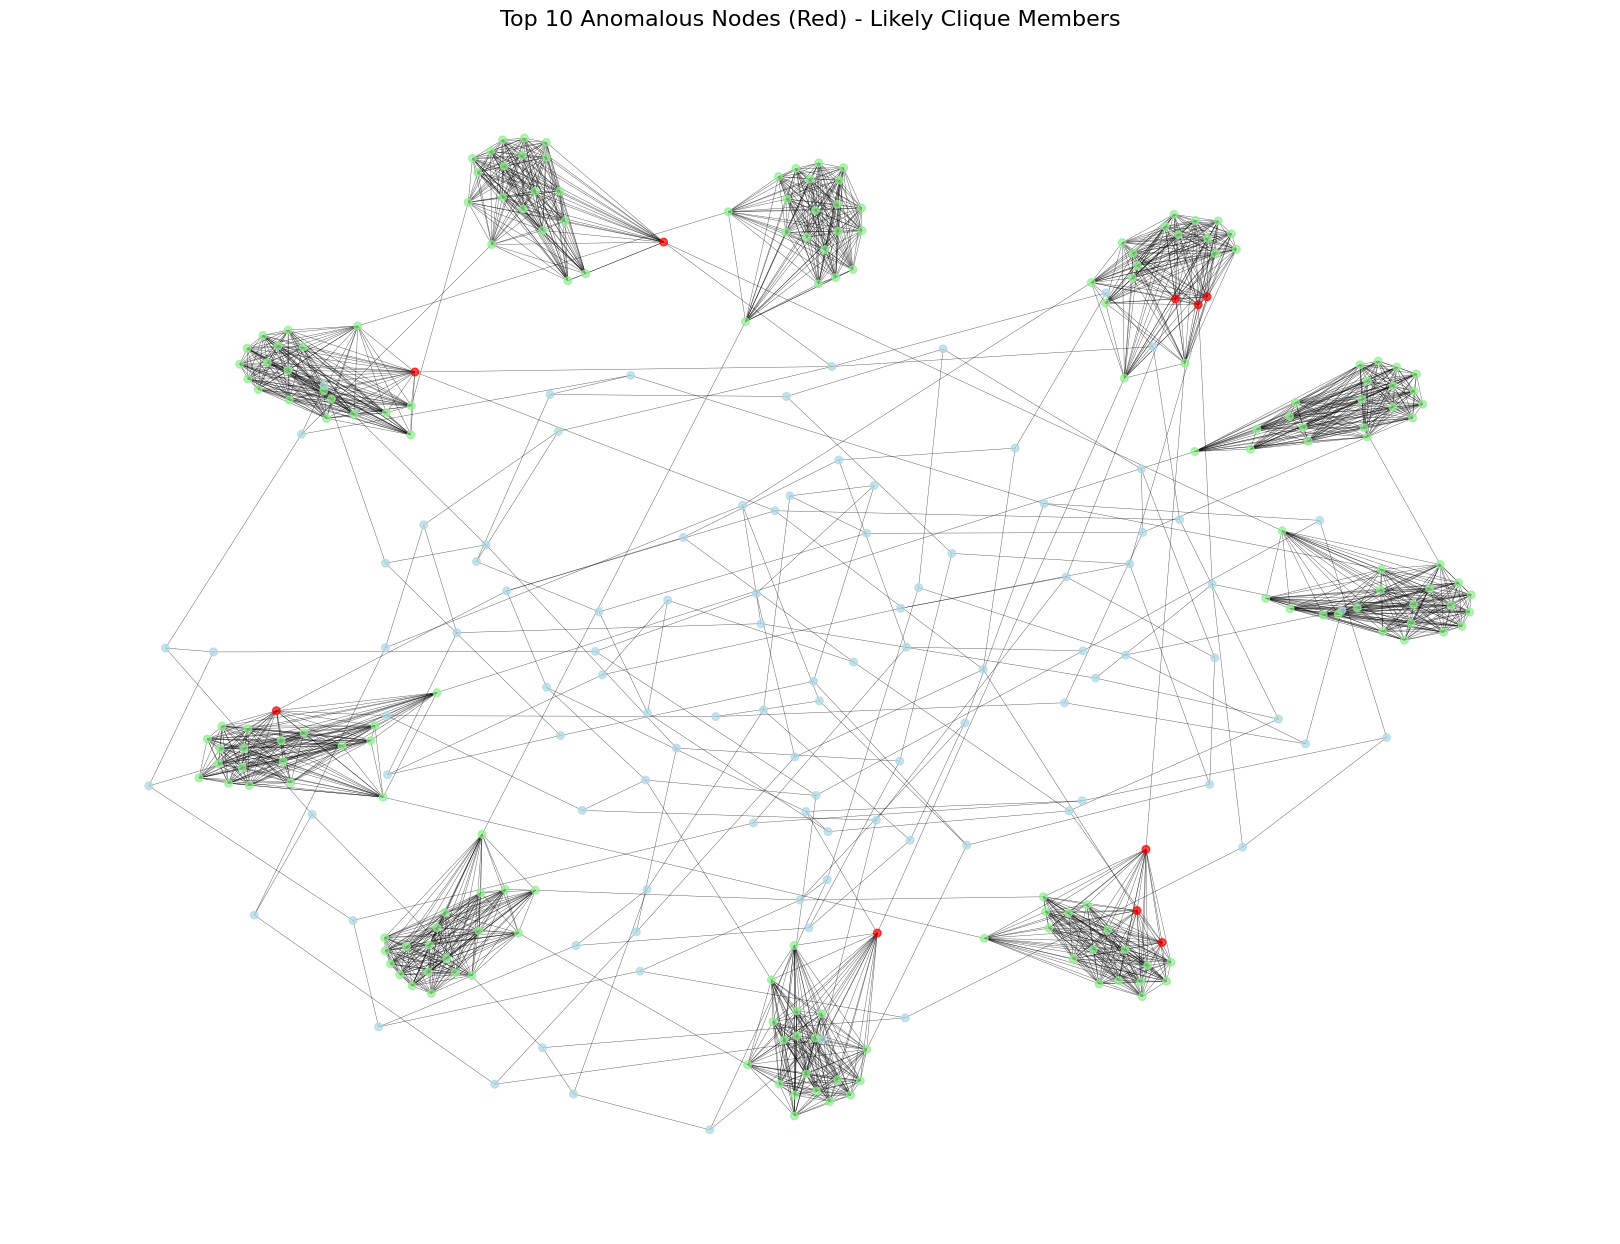

In [8]:
# Create color map highlighting top 10 anomalous nodes
node_colors_anomaly = []
for node in G_merged.nodes():
    if node in top_10_anomalous:
        node_colors_anomaly.append('red')
    elif node.startswith('regular_'):
        node_colors_anomaly.append('lightblue')
    else:
        node_colors_anomaly.append('lightgreen')

plt.figure(figsize=(16, 12))
nx.draw(G_merged, pos, node_color=node_colors_anomaly, node_size=30, 
        width=0.3, alpha=0.7, with_labels=False)
plt.title('Top 10 Anomalous Nodes (Red) - Likely Clique Members', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

## Analysis: Feature Distribution

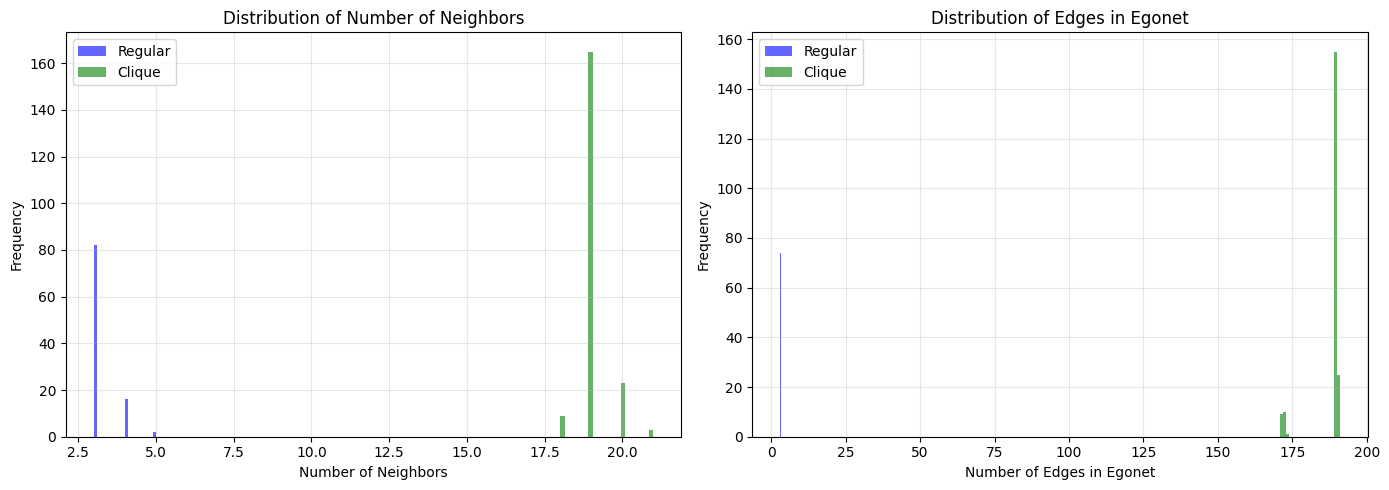

Regular nodes - Avg neighbors: 3.20, Avg edges: 3.29
Clique nodes - Avg neighbors: 19.10, Avg edges: 187.40


In [9]:
# Analyze the distribution of features for regular vs clique nodes
regular_neighbors = [features[n]['num_neighbors'] for n in nodes_list if n.startswith('regular_')]
regular_edges = [features[n]['num_edges'] for n in nodes_list if n.startswith('regular_')]

clique_neighbors = [features[n]['num_neighbors'] for n in nodes_list if n.startswith('clique_')]
clique_edges = [features[n]['num_edges'] for n in nodes_list if n.startswith('clique_')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Number of neighbors
axes[0].hist(regular_neighbors, bins=20, alpha=0.6, label='Regular', color='blue')
axes[0].hist(clique_neighbors, bins=20, alpha=0.6, label='Clique', color='green')
axes[0].set_xlabel('Number of Neighbors')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Number of Neighbors')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Number of edges in egonet
axes[1].hist(regular_edges, bins=20, alpha=0.6, label='Regular', color='blue')
axes[1].hist(clique_edges, bins=20, alpha=0.6, label='Clique', color='green')
axes[1].set_xlabel('Number of Edges in Egonet')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Edges in Egonet')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Regular nodes - Avg neighbors: {np.mean(regular_neighbors):.2f}, Avg edges: {np.mean(regular_edges):.2f}")
print(f"Clique nodes - Avg neighbors: {np.mean(clique_neighbors):.2f}, Avg edges: {np.mean(clique_edges):.2f}")